In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
%matplotlib inline

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")
print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [4]:
nav['date'] = pd.to_datetime(nav['date'])
daily_nav = nav.groupby('date')['nav'].mean().reset_index()
daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


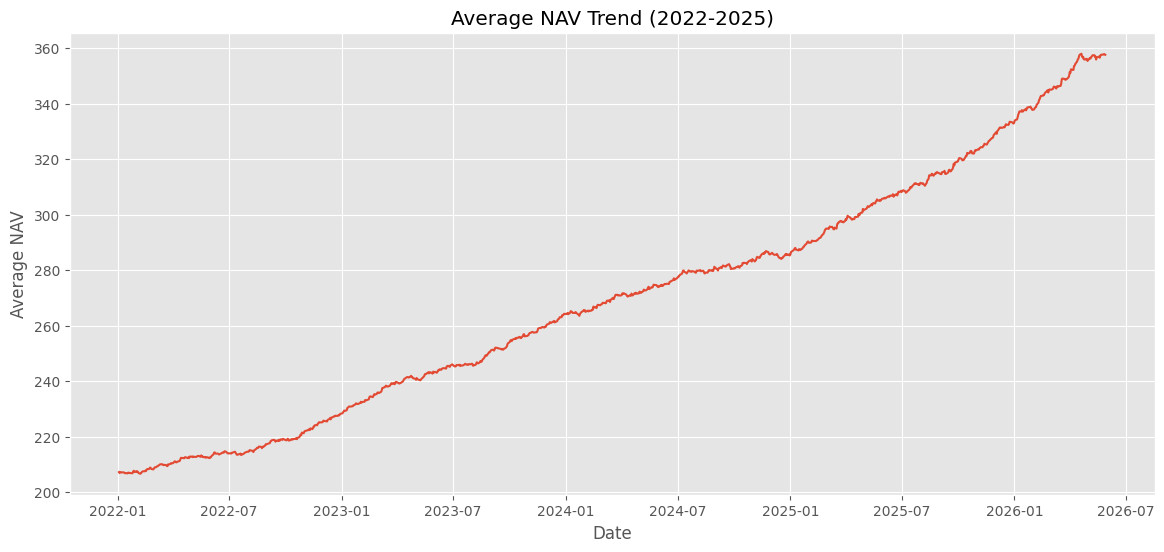

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_nav['date'],
    daily_nav['nav']
)

plt.title("Average NAV Trend (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.show()

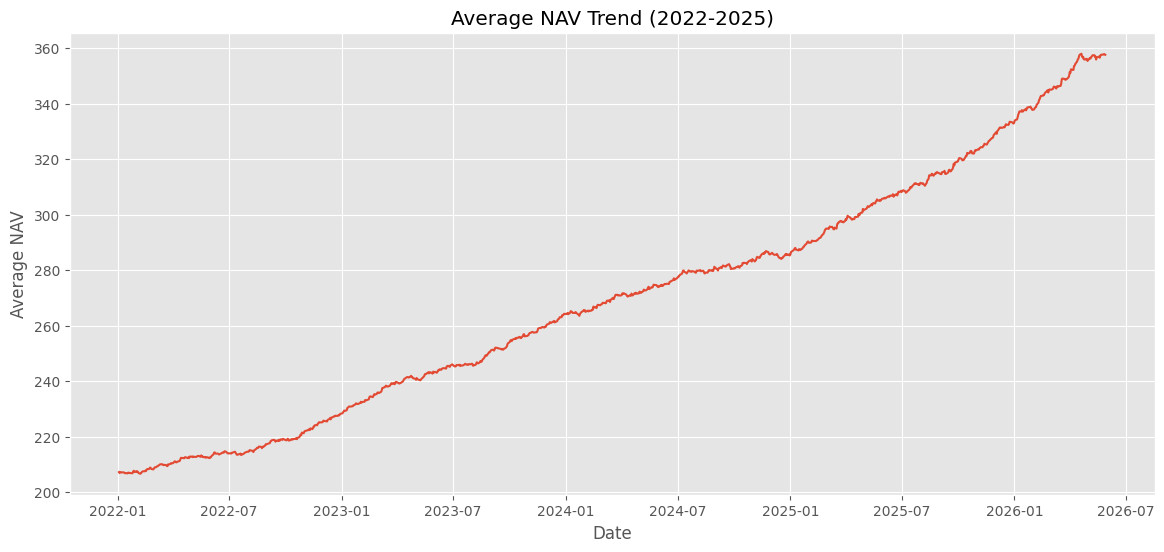

In [6]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_nav['date'],
    daily_nav['nav']
)

plt.title("Average NAV Trend (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.savefig("../reports/nav_trend.png")
plt.show()

In [7]:
daily_nav.describe()

,date,nav
count,1150,1150.000000
mean,2024-03-16 12:00:00,269.570265
min,2022-01-03 00:00:00,206.628312
25%,2023-02-08 06:00:00,233.099221
50%,2024-03-16 12:00:00,269.513807
75%,2025-04-22 18:00:00,299.970628
max,2026-05-29 00:00:00,357.998873
std,NaN,42.510618


In [8]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

print(aum.shape)
aum.head()

(90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [9]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [10]:
aum['date'] = pd.to_datetime(aum['date'])

latest_aum = (
    aum.sort_values('date')
       .groupby('fund_house')
       .tail(1)
)

latest_aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
88,2025-12-31,Mirae Asset MF,2.90,290000,56
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177


In [11]:
top10 = latest_aum.sort_values(
    'aum_crore',
    ascending=False
).head(10)

top10[['fund_house','aum_crore']]

,fund_house,aum_crore
80,SBI Mutual Fund,1250000
81,ICICI Prudential MF,1074000
82,HDFC Mutual Fund,930000
83,Nippon India MF,700000
84,Kotak Mahindra MF,580000
85,Aditya Birla Sun Life MF,460000
87,UTI Mutual Fund,410000
86,Axis Mutual Fund,350000
88,Mirae Asset MF,290000
89,DSP Mutual Fund,230000


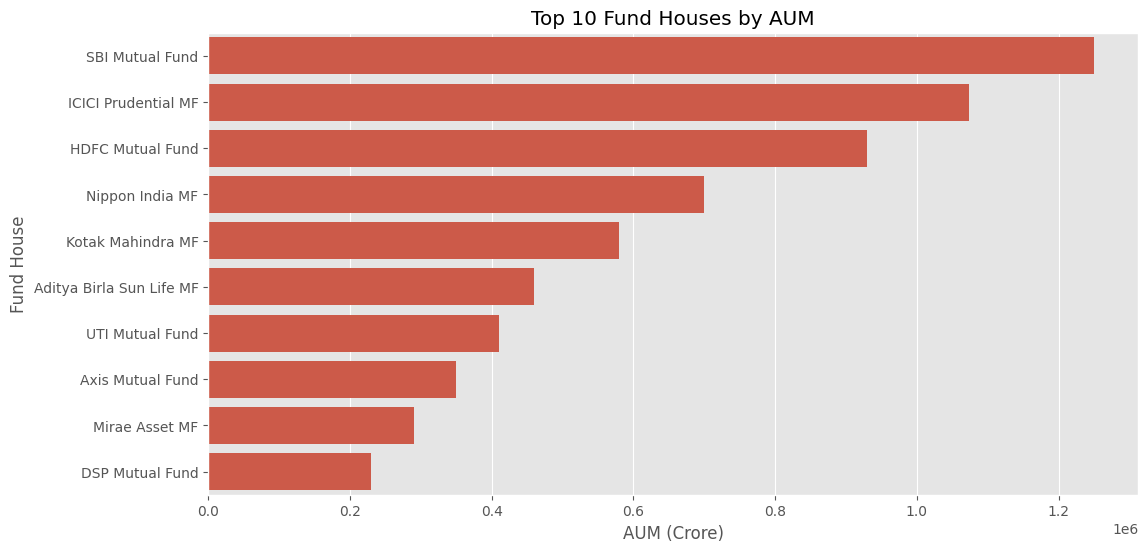

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='aum_crore',
    y='fund_house'
)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Fund House")

plt.show()

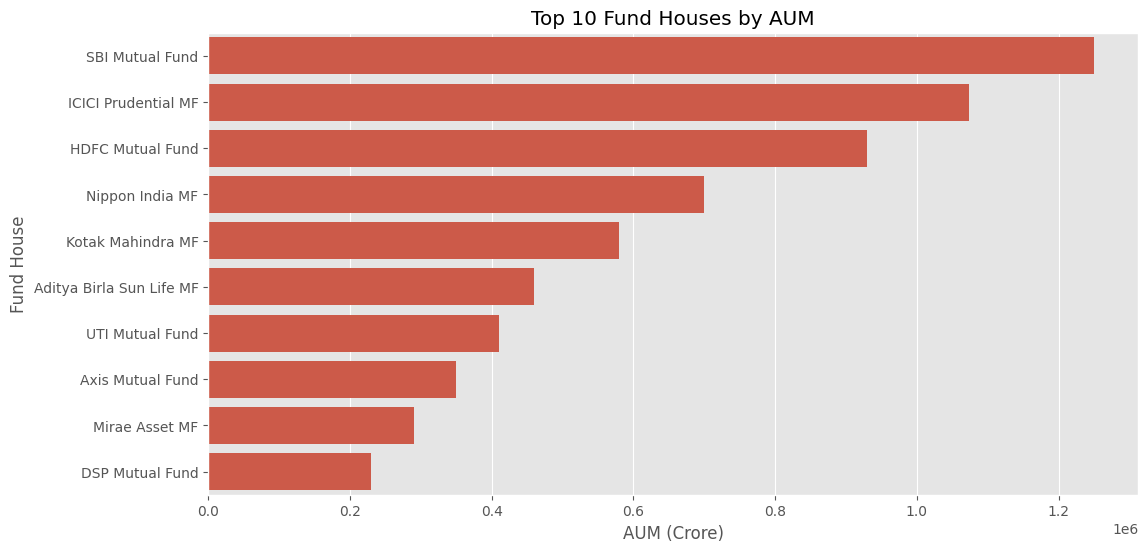

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='aum_crore',
    y='fund_house'
)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Fund House")

plt.savefig("../reports/aum_growth.png")
plt.show()

In [14]:
top10[['fund_house','aum_crore']]

,fund_house,aum_crore
80,SBI Mutual Fund,1250000
81,ICICI Prudential MF,1074000
82,HDFC Mutual Fund,930000
83,Nippon India MF,700000
84,Kotak Mahindra MF,580000
85,Aditya Birla Sun Life MF,460000
87,UTI Mutual Fund,410000
86,Axis Mutual Fund,350000
88,Mirae Asset MF,290000
89,DSP Mutual Fund,230000


In [15]:
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

print(sip.shape)
sip.head()

(48, 6)


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,28.295
1,2022-02,11438,4.93,8.20,4.85,28.295
2,2022-03,12328,5.09,10.50,5.01,28.295
3,2022-04,11863,5.48,9.52,5.12,28.295
4,2022-05,12286,5.55,8.10,5.15,28.295


In [16]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

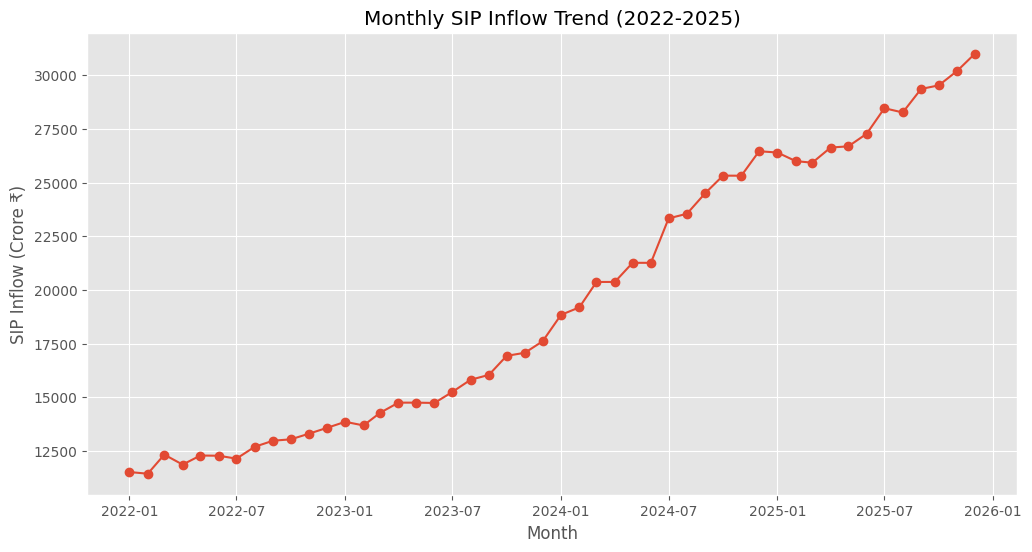

In [17]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))
plt.plot(sip['month'], sip['sip_inflow_crore'], marker='o')

plt.title('Monthly SIP Inflow Trend (2022-2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore ₹)')
plt.grid(True)

plt.show()

In [18]:
sip.loc[sip['sip_inflow_crore'].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

## SIP Inflow Trend Analysis

Observations:

- SIP inflows show a generally increasing trend from 2022 to 2025.
- The highest SIP inflow was recorded in December 2025 at ₹31,002 Crore.
- Active SIP accounts increased steadily, indicating growing retail investor participation.
- SIP AUM reached approximately ₹15.9 lakh crore by the end of 2025.
- The trend reflects increasing investor confidence in mutual fund SIP investments.

In [19]:
import os
os.listdir("../data/processed")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'axis_bluechip_nav.csv',
 'hdfc_top100_live_nav.csv',
 'hdfc_top100_nav.csv',
 'icici_bluechip_nav.csv',
 'kotak_bluechip_nav.csv',
 'nippon_largecap_nav.csv',
 'sbi_bluechip_nav.csv']

In [20]:
category = pd.read_csv("../data/processed/05_category_inflows.csv")
print(category.shape)
category.head()

(144, 3)


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [21]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


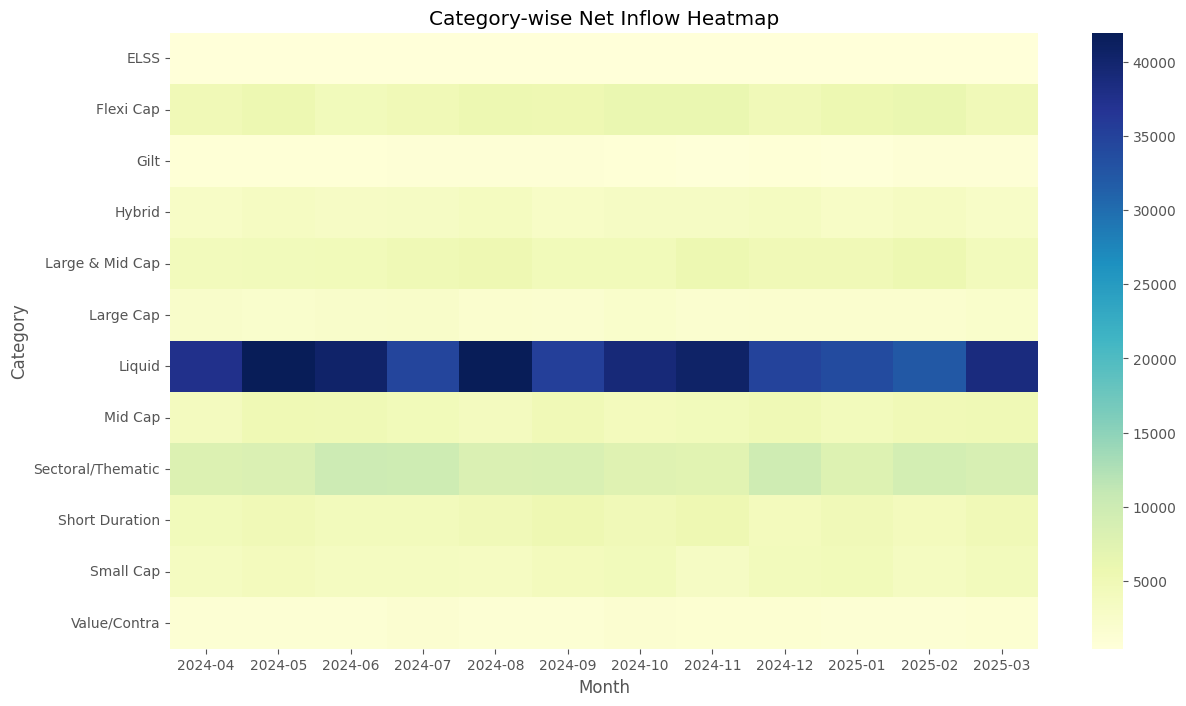

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Category')

plt.show()

## Category-wise Net Inflow Analysis

Observations:

- Equity-oriented categories received the highest inflows.
- Flexi Cap, Mid Cap and Small Cap categories showed strong investor interest.
- Some categories experienced lower inflows during market volatility periods.
- Net inflows remained positive across most categories, indicating sustained participation.
- Category diversification increased over time as investors explored multiple fund types.

In [23]:
investor = pd.read_csv("../data/processed/08_investor_transactions.csv")

print(investor.shape)
investor.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [24]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [25]:
age_dist = investor['age_group'].value_counts()

age_dist

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

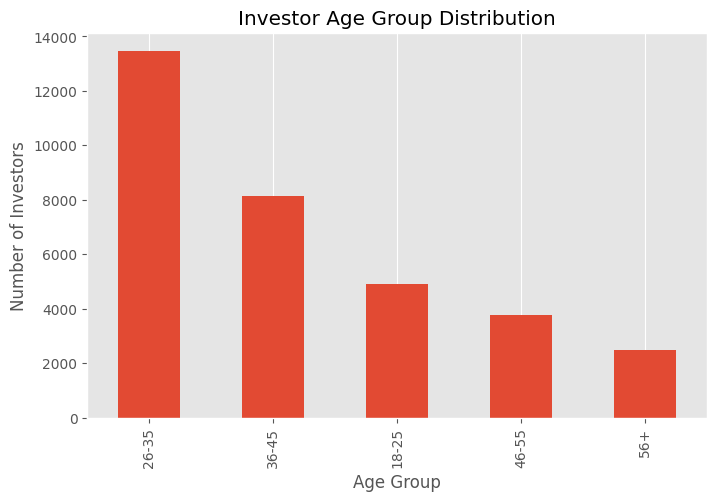

In [26]:
plt.figure(figsize=(8,5))

age_dist.plot(kind='bar')

plt.title('Investor Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Investors')
plt.grid(axis='y')

plt.show()

In [27]:
sip_data = investor[investor['transaction_type'] == 'SIP']

sip_by_age = sip_data.groupby('age_group')['amount_inr'].sum()

sip_by_age

age_group
18-25    32300613
26-35    88587340
36-45    53623247
46-55    25614556
56+      17107735
Name: amount_inr, dtype: int64

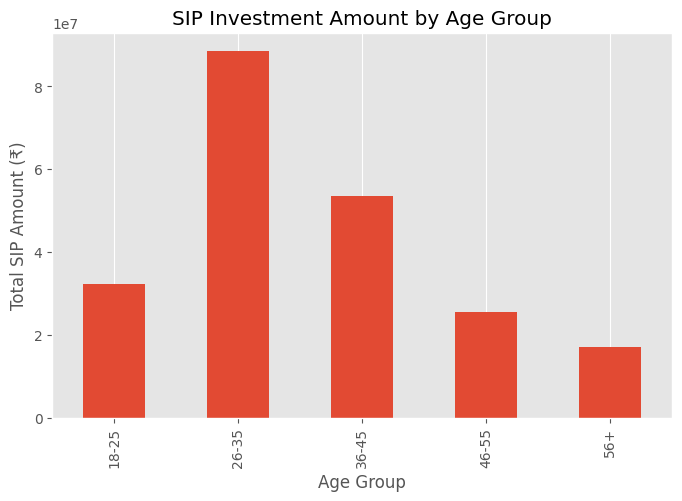

In [28]:
plt.figure(figsize=(8,5))

sip_by_age.plot(kind='bar')

plt.title('SIP Investment Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total SIP Amount (₹)')
plt.grid(axis='y')

plt.show()

## Investor Demographics Analysis

Observations:

- The 26–35 and 36–45 age groups form the largest investor segments.
- SIP participation is highest among working-age investors.
- Younger investors are increasingly adopting SIP investments.
- Investors above 45 continue to contribute significantly to long-term wealth creation.
- The distribution indicates strong retail participation across age groups.

In [29]:
state_sip = investor.groupby('state')['amount_inr'].sum().sort_values(ascending=False)

state_sip.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

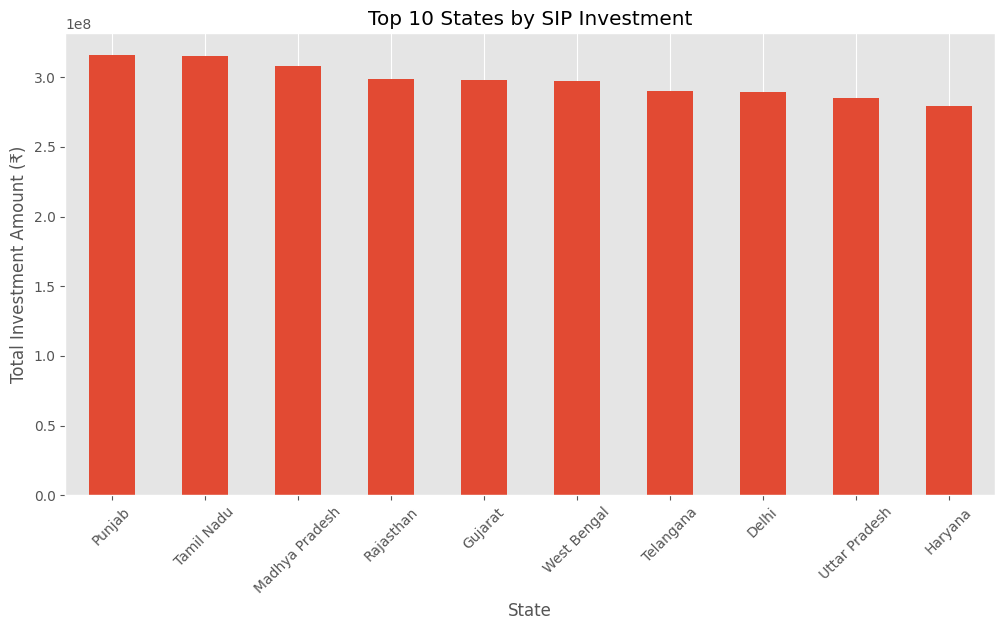

In [30]:
plt.figure(figsize=(12,6))

state_sip.head(10).plot(kind='bar')

plt.title('Top 10 States by SIP Investment')
plt.xlabel('State')
plt.ylabel('Total Investment Amount (₹)')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [31]:
state_sip.idxmax(), state_sip.max()

('Punjab', np.int64(315780459))

## Geographic Distribution Analysis

Observations:

- Investment activity is concentrated in a few major states.
- Urbanized states contribute the largest share of SIP investments.
- Financial awareness and income levels influence investment participation.
- Top states dominate mutual fund inflows.
- Geographic diversification opportunities remain in underpenetrated regions.

## Geographic Distribution Analysis

Observations:

- Punjab recorded the highest SIP investment amount.
- Tamil Nadu and Uttar Pradesh are also major contributors.
- Investment participation is spread across multiple states.
- No single state dominates completely, indicating diversified investor presence.
- Mutual fund penetration is increasing across India.

In [32]:
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

print(folio.shape)
folio.head()

(21, 6)


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [33]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [34]:
folio['month'] = pd.to_datetime(folio['month'])

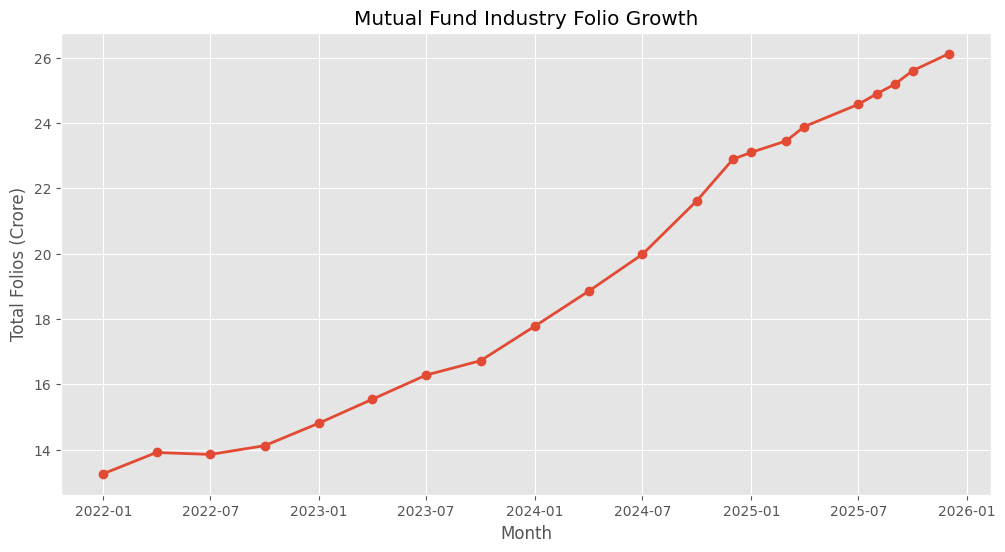

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o',
    linewidth=2
)

plt.title('Mutual Fund Industry Folio Growth')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.grid(True)

plt.show()

In [36]:
folio.loc[folio['total_folios_crore'].idxmax()]

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

In [37]:
folio.loc[folio['total_folios_crore'].idxmin()]

month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object

In [38]:
start = folio['total_folios_crore'].iloc[0]
end = folio['total_folios_crore'].iloc[-1]

growth_pct = ((end - start) / start) * 100

print(f"Folio Growth = {growth_pct:.2f}%")

Folio Growth = 96.98%


## Folio Growth Analysis

Observations:

- Total folios increased steadily throughout the period.
- Growth indicates increasing retail investor participation.
- The mutual fund industry attracted new investors consistently.
- Folio count expansion reflects broader market penetration.
- Long-term growth trend remains strongly positive.

In [39]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [40]:
nav['amfi_code'].nunique()

40

In [41]:
sample_funds = nav['amfi_code'].unique()[:10]

sample_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [42]:
sample_nav = nav[nav['amfi_code'].isin(sample_funds)]

sample_nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [43]:
pivot_nav = sample_nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

pivot_nav.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [44]:
corr_matrix = pivot_nav.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.585294,0.653467,0.753527,0.547031,0.812901,0.749888,-0.326168,0.609280,0.683347
100025,0.585294,1.000000,0.912157,0.893993,0.932599,0.880540,0.799221,-0.466713,0.901961,0.855493
100033,0.653467,0.912157,1.000000,0.954009,0.907721,0.923962,0.882109,-0.390185,0.914544,0.903086
119120,0.753527,0.893993,0.954009,1.000000,0.841035,0.968326,0.910345,-0.389911,0.888482,0.896635
119551,0.547031,0.932599,0.907721,0.841035,1.000000,0.812573,0.834357,-0.484754,0.952277,0.830477
119552,0.812901,0.880540,0.923962,0.968326,0.812573,1.000000,0.862421,-0.386061,0.862105,0.907061
119598,0.749888,0.799221,0.882109,0.910345,0.834357,0.862421,1.000000,-0.294177,0.876745,0.858119
119599,-0.326168,-0.466713,-0.390185,-0.389911,-0.484754,-0.386061,-0.294177,1.000000,-0.417172,-0.344927
125497,0.609280,0.901961,0.914544,0.888482,0.952277,0.862105,0.876745,-0.417172,1.000000,0.856037


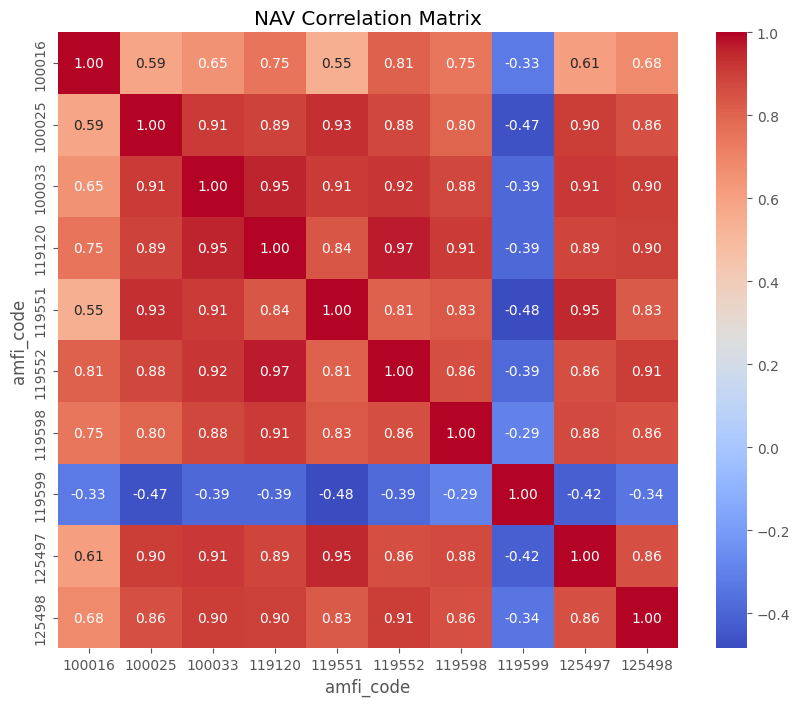

In [45]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Correlation Matrix')
plt.show()

## Correlation Matrix Analysis

Observations:

- Most funds show positive correlation.
- Equity-oriented funds move similarly under market conditions.
- Highly correlated funds provide less diversification benefit.
- Lower correlation indicates diversification opportunities.
- Overall mutual fund performance is influenced by broader market trends.

In [46]:
folio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

print(folio_holdings.shape)
folio_holdings.head()

(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [47]:
folio_holdings['sector'].value_counts()

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

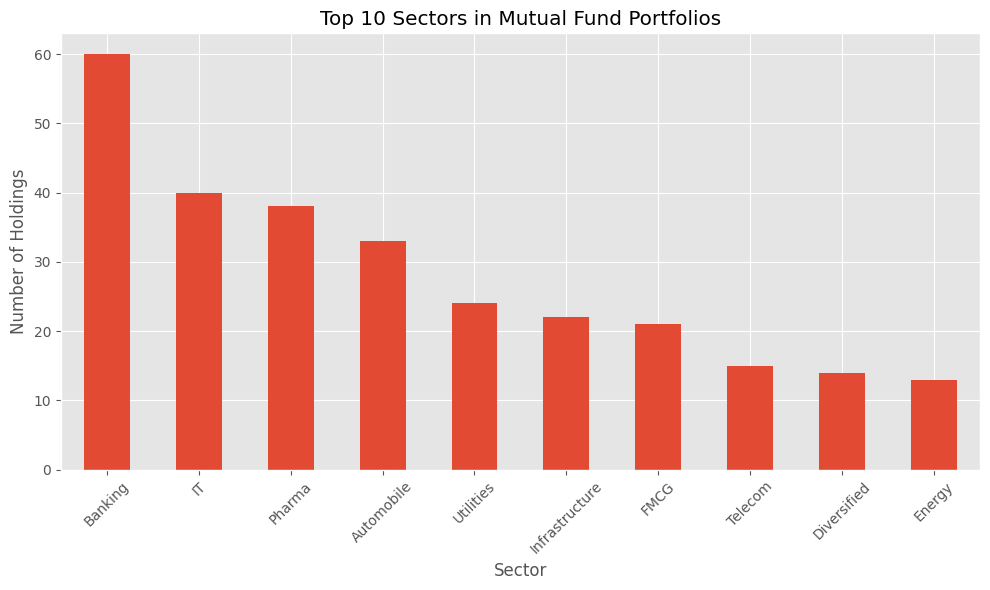

In [48]:
import matplotlib.pyplot as plt

top_sectors = folio_holdings['sector'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_sectors.plot(kind='bar')

plt.title("Top 10 Sectors in Mutual Fund Portfolios")
plt.xlabel("Sector")
plt.ylabel("Number of Holdings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Portfolio Sector Allocation Analysis

Observations:

- Banking is the most represented sector with 60 holdings.
- IT and Pharma sectors also occupy significant portions of portfolios.
- Automobile and Utilities sectors have strong representation.
- Diversification is achieved through exposure to multiple sectors.
- Banking, IT, and Pharma collectively dominate portfolio allocations.
- Sector diversification helps reduce concentration risk.

# Final EDA Summary

## Key Findings

### Mutual Fund NAV Analysis
- NAV values showed a consistent upward trend over time.
- Several funds generated strong long-term returns.
- Most funds exhibited positive correlation with each other.

### Asset Under Management (AUM)
- SBI Mutual Fund maintained the highest AUM.
- Large fund houses dominate industry assets.

### SIP Trends
- Monthly SIP inflows increased significantly over the study period.
- SIP investments reached record highs in late 2025.
- Investor participation continues to grow steadily.

### Category Flow Analysis
- Liquid funds attracted the largest inflows.
- Equity-oriented categories remained popular among investors.

### Investor Behavior
- Investors aged 26–35 contributed the highest SIP volumes.
- Major metropolitan cities generated substantial investment activity.

### Industry Folio Growth
- Total folios increased consistently from 2022 to 2025.
- Equity folios remained the largest contributor to growth.

### Portfolio Allocation
- Banking, IT, and Pharma sectors dominated holdings.
- Portfolios maintained diversification across multiple sectors.

## Conclusion

The Indian mutual fund industry demonstrated strong growth in assets, SIP participation, investor base, and portfolio diversification. Increasing retail participation and sustained SIP inflows indicate a healthy long-term outlook for the industry.